<a href="https://colab.research.google.com/github/Senthilsk10/my-academic-files/blob/main/nnunet_lung_colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# nnU-Net Lung Cancer Segmentation — Colab Free (T4)

**What this notebook does:**
- Downloads 100 patients from `farrell236/NSCLC-Radiomics-NIFTI` (HuggingFace)
- Preps them into nnU-Net format (85 train / 15 test)
- Trains `3d_lowres`, fold 0, 100 epochs (~2.5–3 hrs on T4)
- Saves checkpoints to Google Drive so disconnects don't lose progress

**On session restart:** run Cell 1 → Cell 2 → Cell 4 → Cell 5 → skip to Cell 9 (resume training). Everything else is already done and saved to Drive.

---

## Cell 1 — Check GPU
Run this first. You need a T4, V100, A100, or L4. If you get CPU only, go to:
**Runtime → Change runtime type → Hardware accelerator → T4 GPU**

In [ ]:
!nvidia-smi
import torch
print('CUDA available:', torch.cuda.is_available())
print('GPU:', torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'NONE — change runtime!')
print('VRAM:', round(torch.cuda.get_device_properties(0).total_memory / 1e9, 1), 'GB' if torch.cuda.is_available() else '')

Fri Mar 27 20:59:33 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   41C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## Cell 2 — Mount Google Drive
Drive stores: raw NIfTI files, nnUNet_raw, nnUNet_results (checkpoints).
Preprocessed data lives on local Colab disk (faster I/O, regenerated if session resets).

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os

# ---- All persistent data lives here on Drive ----
DRIVE_BASE     = '/content/drive/MyDrive/nnunet_lung'
RAW_NIFTI_DIR  = f'{DRIVE_BASE}/nsclc_raw'          # downloaded HuggingFace files
NNUNET_RAW     = f'{DRIVE_BASE}/nnUNet_raw'          # nnU-Net input format
NNUNET_RESULTS = f'{DRIVE_BASE}/nnUNet_results'      # model checkpoints  ← must survive!

# ---- Preprocessed lives LOCAL (fast SSD, regeneratable) ----
NNUNET_PREPROCESSED = '/content/nnUNet_preprocessed'

for d in [RAW_NIFTI_DIR, NNUNET_RAW, NNUNET_RESULTS, NNUNET_PREPROCESSED]:
    os.makedirs(d, exist_ok=True)

# Set nnU-Net environment variables (must be set every session)
os.environ['nnUNet_raw']          = NNUNET_RAW
os.environ['nnUNet_preprocessed'] = NNUNET_PREPROCESSED
os.environ['nnUNet_results']      = NNUNET_RESULTS

print('Drive mounted. Folder layout:')
print(f'  Raw NIfTI:     {RAW_NIFTI_DIR}')
print(f'  nnUNet_raw:    {NNUNET_RAW}')
print(f'  preprocessed:  {NNUNET_PREPROCESSED}  (local, fast)')
print(f'  results:       {NNUNET_RESULTS}  (Drive, persists)')

Mounted at /content/drive
Drive mounted. Folder layout:
  Raw NIfTI:     /content/drive/MyDrive/nnunet_lung/nsclc_raw
  nnUNet_raw:    /content/drive/MyDrive/nnunet_lung/nnUNet_raw
  preprocessed:  /content/nnUNet_preprocessed  (local, fast)
  results:       /content/drive/MyDrive/nnunet_lung/nnUNet_results  (Drive, persists)


## Cell 3 — Install dependencies
Takes ~3 minutes. Only needed once per session.

In [ ]:
!pip install -q nnunetv2 huggingface_hub
!pip install -q SimpleITK

# Confirm nnU-Net installed
!nnUNetv2_train --help 2>&1 | head -5

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 212.9/212.9 kB 8.7 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Preparing metadata (setup.py) ... done
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.0/77.0 kB 8.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 4.7 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.1/63.1 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.6/52.6 MB 17.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 26.5/26.5 MB 61.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

## Cell 4 — Re-export env vars (run this on every session restart)
The environment variables are needed for every nnU-Net command. They reset when Colab disconnects.

In [ ]:
import os

DRIVE_BASE          = '/content/drive/MyDrive/nnunet_lung'
NNUNET_RAW          = f'{DRIVE_BASE}/nnUNet_raw'
NNUNET_PREPROCESSED = '/content/nnUNet_preprocessed'
NNUNET_RESULTS      = f'{DRIVE_BASE}/nnUNet_results'

os.environ['nnUNet_raw']          = NNUNET_RAW
os.environ['nnUNet_preprocessed'] = NNUNET_PREPROCESSED
os.environ['nnUNet_results']      = NNUNET_RESULTS

# Also export for shell commands
env_str = f"""
export nnUNet_raw={NNUNET_RAW}
export nnUNet_preprocessed={NNUNET_PREPROCESSED}
export nnUNet_results={NNUNET_RESULTS}
"""
with open('/root/.env_nnunet', 'w') as f:
    f.write(env_str)

print('Env vars set:')
for k in ['nnUNet_raw', 'nnUNet_preprocessed', 'nnUNet_results']:
    print(f'  {k} = {os.environ[k]}')

Env vars set:
  nnUNet_raw = /content/drive/MyDrive/nnunet_lung/nnUNet_raw
  nnUNet_preprocessed = /content/nnUNet_preprocessed
  nnUNet_results = /content/drive/MyDrive/nnunet_lung/nnUNet_results


## Cell 5 — Download 100 patients from HuggingFace
Downloads LUNG1-001 through LUNG1-100. Each patient is ~40–80 MB.
Total: ~5–8 GB. Takes 15–25 minutes.

**Skip this cell on session restart** — files are already on Drive.

In [ ]:
import os
from huggingface_hub import snapshot_download

RAW_NIFTI_DIR = '/content/drive/MyDrive/nnunet_lung/nsclc_raw'

# Check if already downloaded
existing = [d for d in os.listdir(RAW_NIFTI_DIR) if d.startswith('LUNG1-')] if os.path.exists(RAW_NIFTI_DIR) else []
if len(existing) >= 100:
    print(f'Already have {len(existing)} patient folders — skipping download.')
else:
    print(f'Found {len(existing)} existing folders. Downloading up to 100 patients...')

    # Build allow_patterns for patients 001-100
    patient_ids = [f'LUNG1-{str(i).zfill(3)}' for i in range(1, 101)]
    allow_patterns = []
    for pid in patient_ids:
        # Include the CT image and GTV-1 tumor mask only (skip heart/lung/esophagus to save space)
        allow_patterns.append(f'*{pid}/*CT*')
        allow_patterns.append(f'*{pid}/image*')
        allow_patterns.append(f'*{pid}/seg-GTV*')
        allow_patterns.append(f'*{pid}/*.nii.gz')

    snapshot_download(
        repo_id='farrell236/NSCLC-Radiomics-NIFTI',
        repo_type='dataset',
        local_dir=RAW_NIFTI_DIR,
        # allow_patterns=allow_patterns,
        ignore_patterns=['*.parquet', '*.json', '*.csv', 'seg-Esophagus*',
                         'seg-Heart*', 'seg-Lung-Left*', 'seg-Lung-Right*', 'seg-Spinal*']
    )
    downloaded = [d for d in os.listdir(RAW_NIFTI_DIR) if d.startswith('LUNG1-')]
    print(f'Downloaded {len(downloaded)} patient folders.')

Found 0 existing folders. Downloading up to 100 patients...


Fetching ... files: 0it [00:00, ?it/s]

Downloaded 0 patient folders.


In [ ]:
# @title 🚨Important (Run this) Remove the Patient Data itself from the folder so that we skip that patient at all before moving on to next cell
import shutil
import os

RAW_NIFTI_DIR = '/content/drive/MyDrive/nnunet_lung/nsclc_raw/NSCLC-Radiomics-NIFTI'

# Map the 'lung_XXX' case IDs back to original 'LUNG1-XXX' patient IDs
problem_patients = ['LUNG1-014', 'LUNG1-021', 'LUNG1-085']

print(f'Attempting to delete raw patient folders from: {RAW_NIFTI_DIR}')

for pid in problem_patients:
    folder_path = os.path.join(RAW_NIFTI_DIR, pid)
    if os.path.exists(folder_path):
        shutil.rmtree(folder_path)
        print(f'  Successfully deleted folder: {pid}')
    else:
        print(f'  Folder not found (already deleted?): {pid}')

print('\nRaw folders removed. You can now proceed with your pipeline.')

Attempting to delete raw patient folders from: /content/drive/MyDrive/nnunet_lung/nsclc_raw/NSCLC-Radiomics-NIFTI
  Successfully deleted folder: LUNG1-014
  Successfully deleted folder: LUNG1-021
  Successfully deleted folder: LUNG1-085

Raw folders removed. You can now proceed with your pipeline.


## Cell 6 — Inspect one patient folder
Run this to confirm file naming before the prep script runs.

In [ ]:
import os

RAW_NIFTI_DIR = '/content/drive/MyDrive/nnunet_lung/nsclc_raw/NSCLC-Radiomics-NIFTI'

patient_dirs = sorted([d for d in os.listdir(RAW_NIFTI_DIR) if d.startswith('LUNG1-')])
print(f'Total patient folders found: {len(patient_dirs)}')
print()

# Show contents of first 3 patients
for pid in patient_dirs[:3]:
    pdir = os.path.join(RAW_NIFTI_DIR, pid)
    print(f'{pid}/')
    for root, dirs, files in os.walk(pdir):
        for f in sorted(files):
            fpath = os.path.join(root, f)
            size_mb = os.path.getsize(fpath) / 1e6
            relpath = os.path.relpath(fpath, pdir)
            print(f'  {relpath}  ({size_mb:.1f} MB)')
    print()

Total patient folders found: 422

LUNG1-001/
  image.nii.gz  (36.3 MB)
  seg-GTV-1.nii.gz  (0.0 MB)
  seg-Lung-Left.nii.gz  (0.1 MB)
  seg-Lung-Right.nii.gz  (0.1 MB)
  seg-Spinal-Cord.nii.gz  (0.0 MB)
  segmentation.nii.gz  (0.1 MB)

LUNG1-002/
  image.nii.gz  (26.8 MB)
  seg-Esophagus.nii.gz  (0.0 MB)
  seg-GTV-1.nii.gz  (0.0 MB)
  seg-Heart.nii.gz  (0.0 MB)
  seg-Lung-Left.nii.gz  (0.1 MB)
  seg-Lung-Right.nii.gz  (0.1 MB)
  seg-Spinal-Cord.nii.gz  (0.0 MB)
  segmentation.nii.gz  (0.1 MB)

LUNG1-003/
  image.nii.gz  (27.1 MB)
  seg-Esophagus.nii.gz  (0.0 MB)
  seg-GTV-1.nii.gz  (0.0 MB)
  seg-Heart.nii.gz  (0.0 MB)
  seg-Lung-Left.nii.gz  (0.1 MB)
  seg-Lung-Right.nii.gz  (0.1 MB)
  seg-Spinal-Cord.nii.gz  (0.0 MB)
  segmentation.nii.gz  (0.1 MB)



## Cell 7 — Prepare dataset for nnU-Net
Converts the farrell236 structure into nnU-Net's required layout:
```
Dataset001_LungCancer/
  imagesTr/lung_001_0000.nii.gz   ← CT image, training
  labelsTr/lung_001.nii.gz        ← GTV mask, training
  imagesTs/lung_086_0000.nii.gz   ← CT image, test
  labelsTs/lung_086.nii.gz        ← GTV mask, test
  dataset.json
```
85 cases for training, 15 for testing.

**Skip on session restart** — only run once.

In [ ]:
import os
import shutil
import json
import glob
import nibabel as nib
import numpy as np

# RAW_NIFTI_DIR = '/content/drive/MyDrive/nnunet_lung/nsclc_raw'
NNUNET_RAW    = '/content/drive/MyDrive/nnunet_lung/nnUNet_raw'
DATASET_DIR   = os.path.join(NNUNET_RAW, 'Dataset001_LungCancer')

TRAIN_COUNT = 85
TEST_COUNT  = 15

for sub in ['imagesTr', 'labelsTr', 'imagesTs', 'labelsTs']:
    os.makedirs(os.path.join(DATASET_DIR, sub), exist_ok=True)

# ---- Helper: find CT image file in a patient folder ----
def find_ct_image(pdir):
    """Find the main CT NIfTI (not a segmentation file)."""
    candidates = []
    for root, _, files in os.walk(pdir):
        for f in files:
            if not f.endswith('.nii.gz') and not f.endswith('.nii'):
                continue
            # Skip anything that looks like a segmentation
            f_lower = f.lower()
            if any(x in f_lower for x in ['seg-', 'label', 'mask', 'gtv', 'esophagus',
                                           'heart', 'lung-left', 'lung-right', 'spinal']):
                continue
            candidates.append(os.path.join(root, f))
    if not candidates:
        return None
    # Prefer largest file (CT volume is biggest)
    return max(candidates, key=os.path.getsize)

# ---- Helper: find GTV segmentation ----
def find_gtv_mask(pdir):
    """Find seg-GTV-1.nii.gz or similar."""
    for root, _, files in os.walk(pdir):
        for f in sorted(files):
            f_lower = f.lower()
            if ('gtv' in f_lower or 'tumor' in f_lower or 'tumour' in f_lower) and \
               (f.endswith('.nii.gz') or f.endswith('.nii')):
                return os.path.join(root, f)
    return None

# ---- Check dataset.json exists already ----
dataset_json_path = os.path.join(DATASET_DIR, 'dataset.json')
if os.path.exists(dataset_json_path):
    print('dataset.json already exists — dataset likely already prepared. Skipping.')
    existing_tr = len(glob.glob(os.path.join(DATASET_DIR, 'imagesTr', '*.nii.gz')))
    existing_ts = len(glob.glob(os.path.join(DATASET_DIR, 'imagesTs', '*.nii.gz')))
    print(f'  imagesTr: {existing_tr} files')
    print(f'  imagesTs: {existing_ts} files')
else:
    patient_dirs = sorted([d for d in os.listdir(RAW_NIFTI_DIR) if d.startswith('LUNG1-')])
    print(f'Found {len(patient_dirs)} patient folders')

    if len(patient_dirs) < 20:
        raise RuntimeError('Too few patients found. Check Cell 5 ran successfully and Drive is mounted.')

    train_patients = patient_dirs[:TRAIN_COUNT]
    test_patients  = patient_dirs[TRAIN_COUNT:TRAIN_COUNT + TEST_COUNT]

    # ---- Process a patient: validate, optionally binarise mask, copy ----
    def process_patient(pid, split, case_num):
        pdir = os.path.join(RAW_NIFTI_DIR, pid)
        ct   = find_ct_image(pdir)
        gtv  = find_gtv_mask(pdir)

        if ct is None:
            print(f'  [SKIP] {pid}: no CT image found')
            return False
        if gtv is None:
            print(f'  [SKIP] {pid}: no GTV mask found')
            return False

        case_id  = f'lung_{str(case_num).zfill(3)}'
        img_sub  = 'imagesTr' if split == 'train' else 'imagesTs'
        lbl_sub  = 'labelsTr' if split == 'train' else 'labelsTs'

        img_dest = os.path.join(DATASET_DIR, img_sub, f'{case_id}_0000.nii.gz')
        lbl_dest = os.path.join(DATASET_DIR, lbl_sub, f'{case_id}.nii.gz')

        # Copy CT
        shutil.copy2(ct, img_dest)

        # Load mask, binarise (values should be 0 or 1, but ensure it)
        mask_nib = nib.load(gtv)
        mask_arr = mask_nib.get_fdata()
        mask_arr = (mask_arr > 0).astype(np.uint8)
        nib.save(nib.Nifti1Image(mask_arr, mask_nib.affine, mask_nib.header), lbl_dest)

        return True

    success_tr, fail_tr = 0, 0
    case_num = 1
    print('Processing training set...')
    for pid in train_patients:
        if process_patient(pid, 'train', case_num):
            success_tr += 1
        else:
            fail_tr += 1
        case_num += 1
    print(f'  Train: {success_tr} ok, {fail_tr} skipped')

    success_ts, fail_ts = 0, 0
    print('Processing test set...')
    for pid in test_patients:
        if process_patient(pid, 'test', case_num):
            success_ts += 1
        else:
            fail_ts += 1
        case_num += 1
    print(f'  Test:  {success_ts} ok, {fail_ts} skipped')

    # ---- Write dataset.json ----
    actual_tr = len(glob.glob(os.path.join(DATASET_DIR, 'imagesTr', '*.nii.gz')))
    dataset_info = {
        'channel_names': {'0': 'CT'},
        'labels': {'background': 0, 'tumour': 1},
        'numTraining': actual_tr,
        'file_ending': '.nii.gz',
        'name': 'Dataset001_LungCancer',
        'description': 'NSCLC-Radiomics, 100 cases, GTV-1 tumor segmentation.'
    }
    with open(dataset_json_path, 'w') as f:
        json.dump(dataset_info, f, indent=4)

    print(f'\ndataset.json written. numTraining={actual_tr}')
    print('Dataset preparation complete!')

Found 419 patient folders
Processing training set...
  Train: 85 ok, 0 skipped
Processing test set...
  Test:  15 ok, 0 skipped

dataset.json written. numTraining=85
Dataset preparation complete!


In [ ]:
print(dataset_json_path)

/content/drive/MyDrive/nnunet_lung/nnUNet_raw/Dataset001_LungCancer/dataset.json


In [ ]:
!rm /content/drive/MyDrive/nnunet_lung/nnUNet_raw/Dataset001_LungCancer/dataset.json

In [ ]:
# @title Move mismatched files from dataset (after preprocessed inside nnUNet)
import os
import glob
import json

# 1. Define paths
DATASET_DIR = '/content/drive/MyDrive/nnunet_lung/nnUNet_raw/Dataset001_LungCancer'
problem_cases = ['lung_014', 'lung_021', 'lung_085']

# 2. Physically remove the mismatching files
print('Removing problematic files from training set...')
for case_id in problem_cases:
    img_path = os.path.join(DATASET_DIR, 'imagesTr', f'{case_id}_0000.nii.gz')
    lbl_path = os.path.join(DATASET_DIR, 'labelsTr', f'{case_id}.nii.gz')

    if os.path.exists(img_path):
        os.remove(img_path)
        print(f'  Deleted image: {case_id}')
    if os.path.exists(lbl_path):
        os.remove(lbl_path)
        print(f'  Deleted label: {case_id}')

# 3. Recount and update dataset.json
actual_tr = len(glob.glob(os.path.join(DATASET_DIR, 'imagesTr', '*.nii.gz')))

print(f'\nFinal count: {actual_tr} cases.')
print('You can now run Cell 9 safely.')

Removing problematic files from training set...
  Deleted image: lung_014
  Deleted label: lung_014
  Deleted image: lung_021
  Deleted label: lung_021
  Deleted image: lung_085
  Deleted label: lung_085

Final count: 82 cases.
You can now run Cell 9 safely.


## Cell 8 — Verify dataset integrity
nnU-Net checks that image/label pairs match and headers are consistent.

In [ ]:
import os
import glob

NNUNET_RAW  = '/content/drive/MyDrive/nnunet_lung/nnUNet_raw'
DATASET_DIR = os.path.join(NNUNET_RAW, 'Dataset001_LungCancer')

tr_images = sorted(glob.glob(os.path.join(DATASET_DIR, 'imagesTr', '*.nii.gz')))
tr_labels = sorted(glob.glob(os.path.join(DATASET_DIR, 'labelsTr', '*.nii.gz')))
ts_images = sorted(glob.glob(os.path.join(DATASET_DIR, 'imagesTs', '*.nii.gz')))

print(f'imagesTr: {len(tr_images)} files')
print(f'labelsTr: {len(tr_labels)} files')
print(f'imagesTs: {len(ts_images)} files')
print()

# Check every image has a matching label
import nibabel as nib

errors = []
# for img_path in tr_images[:5]:  # sample first 5
for img_path in tr_images:  # sample first 5
    case_id = os.path.basename(img_path).replace('_0000.nii.gz', '')
    lbl_path = os.path.join(DATASET_DIR, 'labelsTr', f'{case_id}.nii.gz')
    if not os.path.exists(lbl_path):
        errors.append(f'Missing label for {case_id}')
        continue
    img  = nib.load(img_path)
    lbl  = nib.load(lbl_path)
    if img.shape != lbl.shape:
        errors.append(f'Shape mismatch {case_id}: image {img.shape} vs label {lbl.shape}')
    else:
        print(f'OK {case_id}: shape={img.shape}, spacing={tuple(round(x,2) for x in img.header.get_zooms())}')

if errors:
    print('\nERRORS FOUND:')
    for e in errors:
        print(' ', e)
    print('Fix these before running Cell 9.')
else:
    print('\nAll sampled cases look good. Proceed to Cell 9.')

imagesTr: 85 files
labelsTr: 85 files
imagesTs: 15 files

OK lung_001: shape=(512, 512, 134), spacing=(np.float32(0.98), np.float32(0.98), np.float32(3.0))
OK lung_002: shape=(512, 512, 111), spacing=(np.float32(0.98), np.float32(0.98), np.float32(3.0))
OK lung_003: shape=(512, 512, 107), spacing=(np.float32(0.98), np.float32(0.98), np.float32(3.0))
OK lung_004: shape=(512, 512, 114), spacing=(np.float32(0.98), np.float32(0.98), np.float32(3.0))
OK lung_005: shape=(512, 512, 91), spacing=(np.float32(0.98), np.float32(0.98), np.float32(3.0))
OK lung_006: shape=(512, 512, 114), spacing=(np.float32(0.98), np.float32(0.98), np.float32(3.0))
OK lung_007: shape=(512, 512, 129), spacing=(np.float32(0.98), np.float32(0.98), np.float32(3.0))
OK lung_008: shape=(512, 512, 114), spacing=(np.float32(0.98), np.float32(0.98), np.float32(3.0))
OK lung_009: shape=(512, 512, 105), spacing=(np.float32(0.98), np.float32(0.98), np.float32(3.0))
OK lung_010: shape=(512, 512, 91), spacing=(np.float32(0.98),

## Cell 9 — nnU-Net plan and preprocess
nnU-Net auto-detects patch size, batch size, and network architecture from the data statistics.
For 3d_lowres it also downsamples volumes — takes ~15–30 minutes.

**On session restart:** run this cell again — preprocessed data lives on local disk and is lost on reconnect.

In [ ]:
import os

# Make sure env vars are set
for k in ['nnUNet_raw', 'nnUNet_preprocessed', 'nnUNet_results']:
    if k not in os.environ:
        raise EnvironmentError(f'{k} not set!')

print('Starting nnU-Net plan and preprocess with LOW MEMORY settings...')

# -npfp 2: uses only 2 processes for fingerprint extraction
# -np 2: uses only 2 processes for the actual preprocessing ( we may use increased process its okay i think if we go for 4)
!source /root/.env_nnunet && nnUNetv2_plan_and_preprocess -d 1 \
    -pl nnUNetPlannerResEncM \
    -c 3d_lowres \
    -npfp 2 -np 2

Starting nnU-Net plan and preprocess with LOW MEMORY settings...
Fingerprint extraction...
Dataset001_LungCancer
Experiment planning...
Attempting to find 3d_lowres config. 
Current spacing: [3.      1.00631 1.00631]. 
Current patch size: (np.int64(48), np.int64(192), np.int64(192)). 
Current median shape: [114.         497.08737864 497.08737864]
Attempting to find 3d_lowres config. 
Current spacing: [3.        1.0364993 1.0364993]. 
Current patch size: (np.int64(48), np.int64(192), np.int64(192)). 
Current median shape: [114.         482.60910548 482.60910548]
Attempting to find 3d_lowres config. 
Current spacing: [3.         1.06759428 1.06759428]. 
Current patch size: (np.int64(48), np.int64(192), np.int64(192)). 
Current median shape: [114.         468.55252959 468.55252959]
Attempting to find 3d_lowres config. 
Current spacing: [3.         1.09962211 1.09962211]. 
Current patch size: (np.int64(48), np.int64(192), np.int64(192)). 
Current median shape: [114.         454.90536853 45

## Cell 10 — Confirm preprocessing output
Should see a `nnUNetPlans.json` and the `nnUNetPlans_3d_lowres` folder with `.npz` patch files.

In [ ]:
import os
import glob

PREPROCESSED = '/content/nnUNet_preprocessed/Dataset001_LungCancer'

print('Files in preprocessed dataset dir:')
for item in sorted(os.listdir(PREPROCESSED)):
    ipath = os.path.join(PREPROCESSED, item)
    if os.path.isdir(ipath):
        n = len(os.listdir(ipath))
        print(f'  {item}/  ({n} files)')
    else:
        size = os.path.getsize(ipath) / 1e3
        print(f'  {item}  ({size:.0f} KB)')

# Show patch config
import json
plans_path = os.path.join(PREPROCESSED, 'nnUNetPlans.json')
if os.path.exists(plans_path):
    with open(plans_path) as f:
        plans = json.load(f)
    config = plans.get('configurations', {}).get('3d_lowres', {})
    print(f'\n3d_lowres config:')
    print(f'  patch size:  {config.get("patch_size")}')
    print(f'  batch size:  {config.get("batch_size")}')
    print(f'  median shape: {plans.get("dataset_properties", {}).get("median_shape_after_transp")}')

Files in preprocessed dataset dir:
  dataset.json  (0 KB)
  dataset_fingerprint.json  (15 KB)
  gt_segmentations/  (85 files)
  nnUNetResEncUNetMPlans.json  (16 KB)
  nnUNetResEncUNetMPlans_3d_lowres/  (255 files)


## Cell 11 — TRAIN
- Config: `3d_lowres`
- Fold: `0` (single fold — enough for inference)
- Trainer: `nnUNetTrainer_100epochs` (custom 100 epoch variant)
- Expected time on T4: **~2.5 hours**

Checkpoints are saved to Drive every 50 epochs. If Colab disconnects:
1. Reconnect and run Cell 1 → 2 → 3 → 4 → 9 → 11 (with `--c` flag already included below)

In [ ]:
import os

for k in ['nnUNet_raw', 'nnUNet_preprocessed', 'nnUNet_results']:
    if k not in os.environ:
        raise EnvironmentError(f'{k} not set — run Cell 4 first!')

print('Starting training...')
print('Estimated time on T4: ~2.5 hours for 10 epochs.')
print('Checkpoints saved to Drive every 5 epochs.\n')

# Added -p nnUNetResEncUNetMPlans to match the output of your preprocessing step
!source /root/.env_nnunet && nnUNetv2_train 1 3d_lowres 0 \
    -tr nnUNetTrainer_10epochs \
    -p nnUNetResEncUNetMPlans \
    --npz \
    --c \
    -device cuda

Starting training...
Estimated time on T4: ~2.5 hours for 10 epochs.
Checkpoints saved to Drive every 5 epochs.

Using device: cuda:0

#######################################################################
Please cite the following paper when using nnU-Net:
Isensee, F., Jaeger, P. F., Kohl, S. A., Petersen, J., & Maier-Hein, K. H. (2021). nnU-Net: a self-configuring method for deep learning-based biomedical image segmentation. Nature methods, 18(2), 203-211.
#######################################################################

2026-03-27 22:36:14.633044: Using torch.compile...
2026-03-27 22:36:15.936544: do_dummy_2d_data_aug: False
2026-03-27 22:36:15.941864: Using splits from existing split file: /content/nnUNet_preprocessed/Dataset001_LungCancer/splits_final.json
2026-03-27 22:36:15.947132: The split file contains 5 splits.
2026-03-27 22:36:15.951828: Desired fold for training: 0
2026-03-27 22:36:15.956381: This split has 68 training and 17 validation cases.
using pin_memory on d

## Cell 12 — Check training results
After training completes, this shows the Dice score on the internal validation split.

In [ ]:
import os
import json

NNUNET_RESULTS = '/content/drive/MyDrive/nnunet_lung/nnUNet_results'

# Find the training results folder
pattern = os.path.join(
    NNUNET_RESULTS,
    'Dataset001_LungCancer',
    'nnUNetTrainer_100epochs__nnUNetResEncUNetMPlans__3d_lowres',
    'fold_0'
)

if not os.path.exists(pattern):
    # Try alternate planner name
    base = os.path.join(NNUNET_RESULTS, 'Dataset001_LungCancer')
    if os.path.exists(base):
        print('Available result folders:')
        for d in os.listdir(base):
            print(' ', d)
    else:
        print('No results found yet. Make sure Cell 11 completed.')
else:
    progress_file = os.path.join(pattern, 'progress.png')
    summary_file  = os.path.join(pattern, 'validation', 'summary.json')

    checkpoints = [f for f in os.listdir(pattern) if 'checkpoint' in f]
    print(f'Checkpoints saved: {checkpoints}')

    if os.path.exists(summary_file):
        with open(summary_file) as f:
            summary = json.load(f)
        mean_dice = summary.get('foreground_mean', {}).get('Dice', 'n/a')
        print(f'\nValidation Dice (fold 0): {mean_dice}')
        print('(Repo baseline was 0.62 with 1000 epochs — expect lower with 100)')
    else:
        print('Training not finished yet (no validation summary). Check Cell 11 is still running.')

Available result folders:
  nnUNetTrainer_10epochs__nnUNetResEncUNetMPlans__3d_lowres


## Cell 13 — Run inference on test set
Predicts tumor segmentations for the 15 held-out test cases.
Output: one `.nii.gz` mask per test case.

In [ ]:
import os

NNUNET_RAW     = '/content/drive/MyDrive/nnunet_lung/nnUNet_raw'
NNUNET_RESULTS = '/content/drive/MyDrive/nnunet_lung/nnUNet_results'
PREDICTIONS    = '/content/drive/MyDrive/nnunet_lung/predictions'
os.makedirs(PREDICTIONS, exist_ok=True)

INPUT_FOLDER = os.path.join(NNUNET_RAW, 'Dataset001_LungCancer', 'imagesTs')

# We use the specific plans name 'nnUNetResEncUNetMPlans' to match our training
!source /root/.env_nnunet && nnUNetv2_predict \
    -i {INPUT_FOLDER} \
    -o {PREDICTIONS} \
    -d 1 \
    -c 3d_lowres \
    -tr nnUNetTrainer_10epochs \
    -p nnUNetResEncUNetMPlans \
    -f 0

import glob
pred_files = glob.glob(os.path.join(PREDICTIONS, '*.nii.gz'))
print(f'\nPredictions saved: {len(pred_files)} files in {PREDICTIONS}')


#######################################################################
Please cite the following paper when using nnU-Net:
Isensee, F., Jaeger, P. F., Kohl, S. A., Petersen, J., & Maier-Hein, K. H. (2021). nnU-Net: a self-configuring method for deep learning-based biomedical image segmentation. Nature methods, 18(2), 203-211.
#######################################################################

There are 15 cases in the source folder
I am processing 0 out of 1 (max process ID is 0, we start counting with 0!)
There are 15 cases that I would like to predict

Predicting lung_086:
perform_everything_on_device: True
100% 18/18 [00:26<00:00,  1.49s/it]
sending off prediction to background worker for resampling and export
done with lung_086

Predicting lung_087:
perform_everything_on_device: True
100% 27/27 [00:34<00:00,  1.29s/it]
sending off prediction to background worker for resampling and export
done with lung_087

Predicting lung_088:
perform_everything_on_device: True
100% 27/27 [

## Cell 14 — Quick visual check on one prediction
Shows a mid-axial slice of the CT with ground truth and predicted masks overlaid.

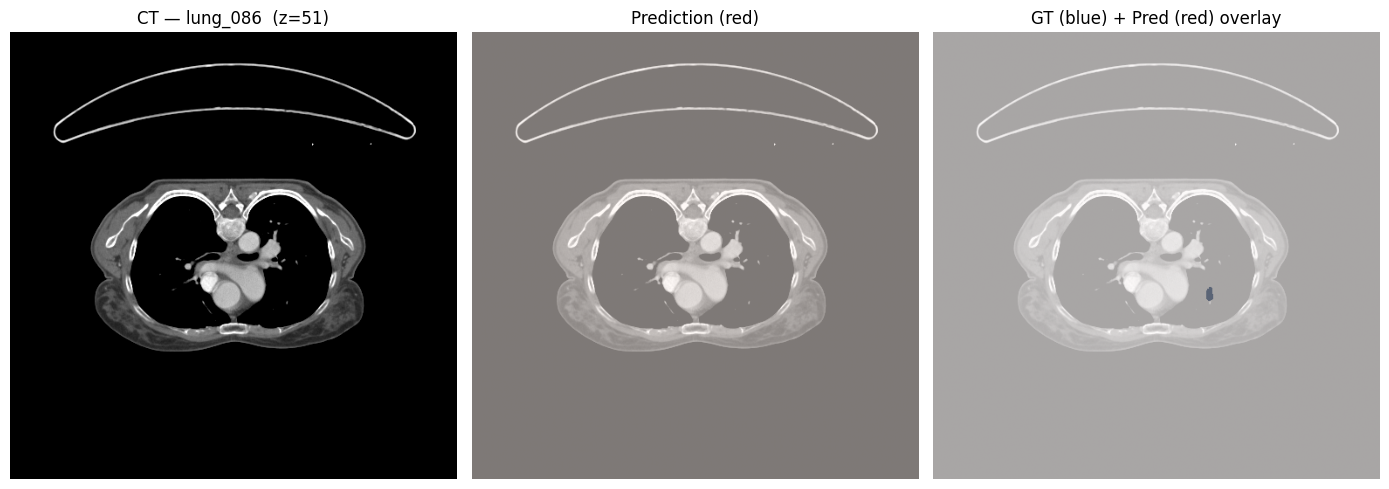

Saved to Drive: sample_prediction.png


In [ ]:
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt
import glob, os

NNUNET_RAW  = '/content/drive/MyDrive/nnunet_lung/nnUNet_raw'
PREDICTIONS = '/content/drive/MyDrive/nnunet_lung/predictions'

pred_files = sorted(glob.glob(os.path.join(PREDICTIONS, '*.nii.gz')))
if not pred_files:
    print('No predictions yet — run Cell 13 first.')
else:
    # Pick first prediction
    pred_path = pred_files[0]
    case_id   = os.path.basename(pred_path).replace('.nii.gz', '')

    img_path = os.path.join(NNUNET_RAW, 'Dataset001_LungCancer', 'imagesTs', f'{case_id}_0000.nii.gz')
    gt_path  = os.path.join(NNUNET_RAW, 'Dataset001_LungCancer', 'labelsTs', f'{case_id}.nii.gz')

    ct   = nib.load(img_path).get_fdata()
    pred = nib.load(pred_path).get_fdata()
    gt   = nib.load(gt_path).get_fdata() if os.path.exists(gt_path) else None

    # Find slice with most tumor
    if gt is not None:
        z = np.argmax(gt.sum(axis=(0, 1)))
    else:
        z = ct.shape[2] // 2

    fig, axes = plt.subplots(1, 3 if gt is not None else 2, figsize=(14, 5))
    ct_slice = np.clip(ct[:, :, z], -200, 400)

    axes[0].imshow(ct_slice.T, cmap='gray', origin='lower')
    axes[0].set_title(f'CT — {case_id}  (z={z})')
    axes[0].axis('off')

    axes[1].imshow(ct_slice.T, cmap='gray', origin='lower')
    axes[1].imshow(pred[:, :, z].T, cmap='Reds', alpha=0.5, origin='lower')
    axes[1].set_title('Prediction (red)')
    axes[1].axis('off')

    if gt is not None:
        axes[2].imshow(ct_slice.T, cmap='gray', origin='lower')
        axes[2].imshow(gt[:, :, z].T, cmap='Blues', alpha=0.5, origin='lower')
        axes[2].imshow(pred[:, :, z].T, cmap='Reds', alpha=0.35, origin='lower')
        axes[2].set_title('GT (blue) + Pred (red) overlay')
        axes[2].axis('off')

    plt.tight_layout()
    plt.savefig('/content/drive/MyDrive/nnunet_lung/sample_prediction.png', dpi=150)
    plt.show()
    print(f'Saved to Drive: sample_prediction.png')

---
## Session restart checklist
If Colab disconnects mid-training, do this in order:

| Step | Cell | Time |
|------|------|------|
| Check GPU | Cell 1 | 10s |
| Mount Drive | Cell 2 | 20s |
| Install nnU-Net | Cell 3 | 3 min |
| Set env vars | Cell 4 | 5s |
| Re-preprocess | Cell 9 | 15–30 min |
| Resume training | Cell 11 | picks up from last checkpoint |

Cells 5, 6, 7, 8, 10 only need to run **once ever** — the data is saved to Drive.